## Operator Distillation

This notebook focuses on study of replacement operator training. Operator replacement is performed by training a replacement using knowledge distillation utilizing calibration data pairs.

problem:

Initial experiments showed bad generalization of selected operators. We have achieved NMSE around 0.5 on validation data which is not usable as a proper fit, ideally we want to achieve $NMSE \leq 0.05$, this we consider a good operator fit.

### Axes of study

This notebook studies how to improve the generalization of local activation distillation while keeping the replacement architecture fixed.

1. **Calibration data** — number and diversity of activation pairs.
2. **Initialization** — random initialization versus teacher-derived weights.
3. **Optimization** — learning rate, schedule, batch size, optimizer, and update budget.
4. **Regularization and loss** — weight decay, early stopping, and regression objective.
5. **Transfer across layers** — whether the selected recipe generalizes beyond the reference block.

Configurations are compared using held-out NMSE, cosine similarity, and the train–validation gap.

### setup

In [1]:
from dataclasses import asdict, replace
from datetime import datetime, timezone
import json
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.capture import ActivationPairs, collect_module_io
from mlp_replacement.config import DataConfig, ModelConfig, OperatorConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import get_mlp_block, load_model_and_tokenizer
from mlp_replacement.operators import GatedMLPReplacement, fit_operator

In [4]:
SEED = 21
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [5]:
EXECUTION_MODE = 'run'

TARGET_LAYER = 11
SWIGLU_WIDTH_RATIO = 0.50

BASELINE_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'baselines-layer-11.json'
)
BASELINE_EXPERIMENTS_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'baseline-experiments.json'
)
OUTPUT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'notebook-block-study'
    / 'operator-distillation.json'
)
RUN_FROM_SCRATCH = EXECUTION_MODE == 'run'
loaded_artifact = (
    None
    if RUN_FROM_SCRATCH
    else json.loads(OUTPUT_PATH.read_text(encoding='utf-8'))
)
if not RUN_FROM_SCRATCH:
    SEED = loaded_artifact['configuration']['seed']
    TARGET_LAYER = loaded_artifact['configuration']['target_layer']
    SWIGLU_WIDTH_RATIO = loaded_artifact['configuration'][
        'swiglu_width_ratio'
    ]

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

baseline_training_config = OperatorConfig(
    kind='swiglu',
    intermediate_ratio=SWIGLU_WIDTH_RATIO,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

In [7]:
if RUN_FROM_SCRATCH:
    model, tokenizer = load_model_and_tokenizer(model_config)
    device = next(model.parameters()).device
else:
    model = tokenizer = device = None

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

In [8]:
loaders = (
    build_data_loaders(
        tokenizer,
        data_config,
        include_recovery=False,
    )
    if RUN_FROM_SCRATCH
    else None
)

Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


In [9]:
if RUN_FROM_SCRATCH:
    block = get_mlp_block(model, TARGET_LAYER)
    hidden_size = int(model.config.hidden_size)
    original_intermediate_width = int(
        block.module.up_proj.out_features
    )
    replacement_width = max(
        1,
        round(SWIGLU_WIDTH_RATIO * original_intermediate_width),
    )
else:
    artifact_configuration = loaded_artifact['configuration']
    TARGET_LAYER = artifact_configuration['target_layer']
    SWIGLU_WIDTH_RATIO = artifact_configuration[
        'swiglu_width_ratio'
    ]
    hidden_size = artifact_configuration['hidden_size']
    original_intermediate_width = artifact_configuration[
        'original_intermediate_width'
    ]
    replacement_width = artifact_configuration[
        'replacement_width'
    ]
    block = None

## Experiments

#### original distillation setting

In [10]:
if RUN_FROM_SCRATCH:
    baseline_artifact = json.loads(
        BASELINE_ARTIFACT_PATH.read_text(encoding='utf-8')
    )
    baseline_experiments_artifact = json.loads(
        BASELINE_EXPERIMENTS_ARTIFACT_PATH.read_text(encoding='utf-8')
    )
    baseline_result = next(
        row
        for row in baseline_artifact['results']
        if row['name'] == 'narrow_swiglu'
    )
    baseline_history_df = pd.DataFrame(
        baseline_artifact['training_histories']['narrow_swiglu']
    )
    calibration_tokens = (
        baseline_artifact['data']['calibration_batches']
        * baseline_artifact['data']['requested_config']['batch_size']
        * baseline_artifact['data']['sequence_length']
    )
    updates_per_epoch = (
        calibration_tokens
        // baseline_artifact['operator_training']['batch_size']
    )
    baseline_epoch_offset = int(
        baseline_history_df['epoch'].min() == 0
    )
    baseline_history_df['optimizer_updates'] = (
        baseline_history_df['epoch'] + baseline_epoch_offset
    ) * updates_per_epoch
    baseline_config_df = pd.DataFrame([
        {'setting': 'target layer', 'value': baseline_artifact['model']['target_layer']},
        {'setting': 'SwiGLU width ratio', 'value': SWIGLU_WIDTH_RATIO},
        {'setting': 'calibration tokens', 'value': calibration_tokens},
        {'setting': 'validation batches', 'value': baseline_artifact['data']['operator_validation_batches']},
        {'setting': 'epoch limit', 'value': baseline_artifact['operator_training']['epochs']},
        {'setting': 'learning rate', 'value': baseline_artifact['operator_training']['learning_rate']},
        {'setting': 'operator batch size', 'value': baseline_artifact['operator_training']['batch_size']},
        {'setting': 'scheduler', 'value': baseline_artifact['operator_training']['scheduler']},
        {'setting': 'weight decay', 'value': baseline_artifact['operator_training']['weight_decay']},
        {'setting': 'early-stopping patience', 'value': baseline_artifact['operator_training']['early_stopping_patience']},
    ])
    baseline_metrics_df = pd.DataFrame([baseline_result])[
        [
            'name',
            'parameters',
            'local_mse',
            'local_relative_mse',
            'local_cosine',
            'local_r2',
            'local_norm_ratio',
            'median_token_relative_error',
            'p95_token_relative_error',
        ]
    ]
else:
    original_results = loaded_artifact['results'][
        'original_distillation'
    ]
    baseline_config_df = pd.DataFrame(
        original_results['configuration']
    )
    baseline_metrics_df = pd.DataFrame(
        original_results['metrics']
    )
    baseline_history_df = pd.DataFrame(
        original_results['training_history']
    )
    calibration_tokens = loaded_artifact['configuration'][
        'original_calibration_tokens'
    ]

display(baseline_config_df)
display(baseline_metrics_df)

,setting,value
0,target layer,11
1,SwiGLU width ratio,0.5
2,calibration tokens,12288
3,validation batches,24
4,epoch limit,64
5,learning rate,0.001
6,operator batch size,2048
7,scheduler,constant
8,weight decay,0.0
9,early-stopping patience,3


,name,parameters,local_mse,local_relative_mse,local_cosine,local_r2,local_norm_ratio,median_token_relative_error,p95_token_relative_error
0,narrow_swiglu,25165824,0.977037,0.626773,0.616157,0.351203,0.656926,0.794837,0.884202


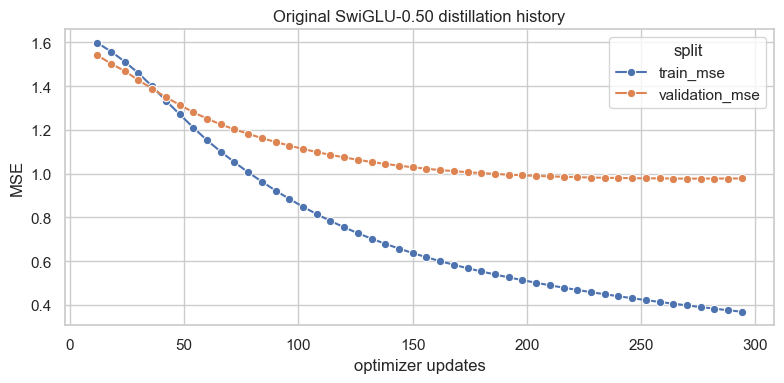

In [11]:
baseline_history_long = baseline_history_df.melt(
    id_vars='optimizer_updates',
    value_vars=['train_mse', 'validation_mse'],
    var_name='split',
    value_name='mse',
)

plt.figure(figsize=(8, 4))
sns.lineplot(
    data=baseline_history_long,
    x='optimizer_updates',
    y='mse',
    hue='split',
    marker='o',
)
plt.title('Original SwiGLU-0.50 distillation history')
plt.xlabel('optimizer updates')
plt.ylabel('MSE')
plt.tight_layout()
plt.show()

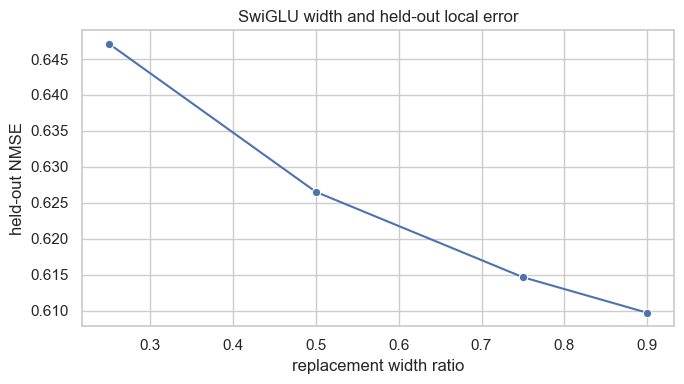

In [12]:
width_scaling_df = pd.DataFrame(
    baseline_experiments_artifact['results']['swiglu_width_scaling']
    if RUN_FROM_SCRATCH
    else loaded_artifact['results']['original_distillation'][
        'width_scaling'
    ]
).sort_values('width_ratio')

plt.figure(figsize=(7, 4))
sns.lineplot(
    data=width_scaling_df,
    x='width_ratio',
    y='local_relative_mse',
    marker='o',
)
plt.title('SwiGLU width and held-out local error')
plt.xlabel('replacement width ratio')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

### Fitting improvements

#### calibration data increase

In [ ]:
CALIBRATION_BATCH_BUDGETS = [48, 96, 192, 384]
CALIBRATION_UPDATE_BUDGET = baseline_training_config.epochs * ceil(
    calibration_tokens / baseline_training_config.batch_size
)
if not RUN_FROM_SCRATCH:
    CALIBRATION_BATCH_BUDGETS = loaded_artifact['configuration'][
        'calibration_batch_budgets'
    ]
    CALIBRATION_UPDATE_BUDGET = loaded_artifact['configuration'][
        'calibration_update_budget'
    ]

In [ ]:
if RUN_FROM_SCRATCH:
    calibration_study_data_config = replace(
        data_config,
        num_calibration_batches=max(CALIBRATION_BATCH_BUDGETS),
    )
    calibration_study_loaders = build_data_loaders(
        tokenizer,
        calibration_study_data_config,
        include_recovery=False,
    )
    calibration_training_pool = collect_module_io(
        model,
        block.path,
        calibration_study_loaders.calibration,
        max(CALIBRATION_BATCH_BUDGETS),
        device,
    )
    calibration_validation_pairs = collect_module_io(
        model,
        block.path,
        calibration_study_loaders.operator_validation,
        data_config.num_operator_validation_batches,
        device,
    )
else:
    calibration_study_data_config = None
    calibration_study_loaders = None
    calibration_training_pool = None
    calibration_validation_pairs = None

tokens_per_capture_batch = (
    data_config.batch_size * data_config.sequence_length
)
calibration_rows = []
calibration_history_rows = []

for num_batches in (
    CALIBRATION_BATCH_BUDGETS if RUN_FROM_SCRATCH else []
):
    num_tokens = num_batches * tokens_per_capture_batch
    training_pairs = ActivationPairs(
        inputs=calibration_training_pool.inputs[:num_tokens],
        targets=calibration_training_pool.targets[:num_tokens],
    )
    steps_per_epoch = ceil(
        num_tokens / baseline_training_config.batch_size
    )
    epoch_limit = ceil(
        CALIBRATION_UPDATE_BUDGET / steps_per_epoch
    )
    training_config = replace(
        baseline_training_config,
        epochs=epoch_limit,
        early_stopping_patience=None,
    )

    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        training_pairs,
        calibration_validation_pairs,
        training_config,
        device,
    )
    metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        training_config.batch_size,
    )
    best_history = next(
        epoch for epoch in fit.history
        if epoch.epoch == fit.best_epoch
    )

    calibration_rows.append({
        'calibration_batches': num_batches,
        'calibration_tokens': num_tokens,
        'epoch_limit': epoch_limit,
        'optimizer_updates': len(fit.history) * steps_per_epoch,
        'best_epoch': fit.best_epoch,
        'best_train_mse': best_history.train_mse,
        'best_validation_mse': fit.best_validation_mse,
        'train_validation_gap': (
            fit.best_validation_mse - best_history.train_mse
        ),
        'heldout_nmse': metrics.relative_mse,
        'heldout_cosine': metrics.cosine_similarity,
    })
    for epoch in fit.history:
        calibration_history_rows.append({
            'calibration_tokens': num_tokens,
            'epoch': epoch.epoch,
            'optimizer_updates': epoch.epoch * steps_per_epoch,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

if RUN_FROM_SCRATCH:
    calibration_study_df = pd.DataFrame(calibration_rows)
    calibration_history_df = pd.DataFrame(
        calibration_history_rows
    )
else:
    calibration_results = loaded_artifact['results'][
        'calibration_data'
    ]
    calibration_study_df = pd.DataFrame(
        calibration_results['summary']
    )
    calibration_history_df = pd.DataFrame(
        calibration_results['training_history']
    )

In [ ]:
display(calibration_study_df)

In [ ]:
calibration_history_plot_df = calibration_history_df.copy()
calibration_history_plot_df['calibration budget'] = (
    calibration_history_plot_df['calibration_tokens']
    .map(lambda value: f'{value:,}')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=calibration_history_plot_df,
    x='optimizer_updates',
    y='train_mse',
    hue='calibration budget',
    ax=axes[0],
)
sns.lineplot(
    data=calibration_history_plot_df,
    x='optimizer_updates',
    y='validation_mse',
    hue='calibration budget',
    ax=axes[1],
)
axes[0].set(title='Training history', ylabel='MSE')
axes[1].set(title='Validation history', ylabel='MSE')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
sns.lineplot(
    data=calibration_study_df,
    x='calibration_tokens',
    y='heldout_nmse',
    marker='o',
)
plt.title('Calibration data and held-out local error')
plt.xlabel('calibration activation pairs')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

#### training optimizations

In [ ]:
TRAINING_OPTIMIZATION_SPECS = [
    {
        'configuration': 'baseline',
        'learning_rate': 1e-3,
        'scheduler': 'constant',
        'weight_decay': 0.0,
    },
    {
        'configuration': 'lower_lr',
        'learning_rate': 3e-4,
        'scheduler': 'constant',
        'weight_decay': 0.0,
    },
    {
        'configuration': 'higher_lr',
        'learning_rate': 3e-3,
        'scheduler': 'constant',
        'weight_decay': 0.0,
    },
    {
        'configuration': 'cosine',
        'learning_rate': 1e-3,
        'scheduler': 'cosine',
        'weight_decay': 0.0,
    },
    {
        'configuration': 'light_decay',
        'learning_rate': 1e-3,
        'scheduler': 'constant',
        'weight_decay': 1e-4,
    },
    {
        'configuration': 'stronger_decay',
        'learning_rate': 1e-3,
        'scheduler': 'constant',
        'weight_decay': 1e-3,
    },
]
if not RUN_FROM_SCRATCH:
    TRAINING_OPTIMIZATION_SPECS = loaded_artifact[
        'configuration'
    ]['training_optimization_specs']

In [ ]:
optimization_calibration_tokens = (
    data_config.num_calibration_batches
    * data_config.batch_size
    * data_config.sequence_length
)
optimization_training_pairs = (
    ActivationPairs(
        inputs=calibration_training_pool.inputs[
            :optimization_calibration_tokens
        ],
        targets=calibration_training_pool.targets[
            :optimization_calibration_tokens
        ],
    )
    if RUN_FROM_SCRATCH
    else None
)
optimization_steps_per_epoch = ceil(
    optimization_calibration_tokens
    / baseline_training_config.batch_size
)
optimization_epoch_limit = ceil(
    CALIBRATION_UPDATE_BUDGET
    / optimization_steps_per_epoch
)

optimization_rows = []
optimization_history_rows = []

for spec in (
    TRAINING_OPTIMIZATION_SPECS if RUN_FROM_SCRATCH else []
):
    training_config = replace(
        baseline_training_config,
        epochs=optimization_epoch_limit,
        learning_rate=spec['learning_rate'],
        scheduler=spec['scheduler'],
        weight_decay=spec['weight_decay'],
        early_stopping_patience=None,
    )

    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        optimization_training_pairs,
        calibration_validation_pairs,
        training_config,
        device,
    )
    metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        training_config.batch_size,
    )
    best_history = next(
        epoch for epoch in fit.history
        if epoch.epoch == fit.best_epoch
    )

    optimization_rows.append({
        **spec,
        'batch_size': training_config.batch_size,
        'optimizer_updates': (
            len(fit.history) * optimization_steps_per_epoch
        ),
        'best_epoch': fit.best_epoch,
        'best_optimizer_update': (
            fit.best_epoch * optimization_steps_per_epoch
        ),
        'train_mse_at_best': best_history.train_mse,
        'best_validation_mse': fit.best_validation_mse,
        'train_validation_gap': (
            fit.best_validation_mse - best_history.train_mse
        ),
        'heldout_nmse': metrics.relative_mse,
        'heldout_cosine': metrics.cosine_similarity,
    })
    for epoch in fit.history:
        optimization_history_rows.append({
            'configuration': spec['configuration'],
            'epoch': epoch.epoch,
            'optimizer_updates': (
                epoch.epoch * optimization_steps_per_epoch
            ),
            'learning_rate': epoch.learning_rate,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

if RUN_FROM_SCRATCH:
    training_optimization_df = pd.DataFrame(optimization_rows)
    training_optimization_history_df = pd.DataFrame(
        optimization_history_rows
    )
    best_training_configuration = (
        training_optimization_df
        .sort_values('heldout_nmse')
        .iloc[0]['configuration']
    )
    best_training_spec = next(
        spec.copy() for spec in TRAINING_OPTIMIZATION_SPECS
        if spec['configuration'] == best_training_configuration
    )
else:
    optimization_results = loaded_artifact['results'][
        'training_optimization'
    ]
    training_optimization_df = pd.DataFrame(
        optimization_results['summary']
    )
    training_optimization_history_df = pd.DataFrame(
        optimization_results['training_history']
    )
    best_training_configuration = optimization_results[
        'best_configuration'
    ]
    best_training_spec = optimization_results['best_spec']

In [ ]:
training_optimization_report_df = (
    training_optimization_df
    .sort_values('heldout_nmse')
    .reset_index(drop=True)
)
display(training_optimization_report_df)
print(f'Best configuration: {best_training_configuration}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=training_optimization_history_df,
    x='optimizer_updates',
    y='train_mse',
    hue='configuration',
    ax=axes[0],
)
sns.lineplot(
    data=training_optimization_history_df,
    x='optimizer_updates',
    y='validation_mse',
    hue='configuration',
    ax=axes[1],
)
axes[0].set(title='Training history', ylabel='MSE')
axes[1].set(title='Validation history', ylabel='MSE')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=training_optimization_report_df,
    x='configuration',
    y='heldout_nmse',
    order=training_optimization_report_df['configuration'],
)
plt.title('Training configuration comparison')
plt.xlabel('configuration')
plt.ylabel('held-out NMSE')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

#### calibration data + training optimizations

In [ ]:
combined_rows = []
combined_history_rows = []

for num_batches in (
    CALIBRATION_BATCH_BUDGETS if RUN_FROM_SCRATCH else []
):
    num_tokens = num_batches * tokens_per_capture_batch
    training_pairs = ActivationPairs(
        inputs=calibration_training_pool.inputs[:num_tokens],
        targets=calibration_training_pool.targets[:num_tokens],
    )
    steps_per_epoch = ceil(
        num_tokens / baseline_training_config.batch_size
    )
    epoch_limit = ceil(
        CALIBRATION_UPDATE_BUDGET / steps_per_epoch
    )
    training_config = replace(
        baseline_training_config,
        epochs=epoch_limit,
        learning_rate=best_training_spec['learning_rate'],
        scheduler=best_training_spec['scheduler'],
        weight_decay=best_training_spec['weight_decay'],
        early_stopping_patience=None,
    )

    torch.manual_seed(SEED)
    fit = fit_operator(
        GatedMLPReplacement(
            hidden_size, replacement_width, bias=False
        ),
        training_pairs,
        calibration_validation_pairs,
        training_config,
        device,
    )
    metrics = evaluate_operator(
        fit.module,
        calibration_validation_pairs,
        device,
        training_config.batch_size,
    )
    best_history = next(
        epoch for epoch in fit.history
        if epoch.epoch == fit.best_epoch
    )

    combined_rows.append({
        'calibration_batches': num_batches,
        'calibration_tokens': num_tokens,
        'configuration': best_training_configuration,
        'optimizer_updates': len(fit.history) * steps_per_epoch,
        'best_epoch': fit.best_epoch,
        'best_optimizer_update': (
            fit.best_epoch * steps_per_epoch
        ),
        'train_mse_at_best': best_history.train_mse,
        'best_validation_mse': fit.best_validation_mse,
        'train_validation_gap': (
            fit.best_validation_mse - best_history.train_mse
        ),
        'heldout_nmse': metrics.relative_mse,
        'heldout_cosine': metrics.cosine_similarity,
    })
    for epoch in fit.history:
        combined_history_rows.append({
            'calibration_tokens': num_tokens,
            'epoch': epoch.epoch,
            'optimizer_updates': epoch.epoch * steps_per_epoch,
            'train_mse': epoch.train_mse,
            'validation_mse': epoch.validation_mse,
        })

if RUN_FROM_SCRATCH:
    combined_training_df = pd.DataFrame(combined_rows)
    combined_training_history_df = pd.DataFrame(
        combined_history_rows
    )
    combined_comparison_df = (
        calibration_study_df[
            ['calibration_tokens', 'heldout_nmse']
        ]
        .rename(columns={'heldout_nmse': 'original_nmse'})
        .merge(
            combined_training_df[
                [
                    'calibration_tokens',
                    'heldout_nmse',
                    'heldout_cosine',
                    'train_validation_gap',
                ]
            ].rename(columns={'heldout_nmse': 'optimized_nmse'}),
            on='calibration_tokens',
        )
    )
    combined_comparison_df['nmse_reduction'] = (
        combined_comparison_df['original_nmse']
        - combined_comparison_df['optimized_nmse']
    )
else:
    combined_results = loaded_artifact['results']['combined']
    combined_training_df = pd.DataFrame(
        combined_results['summary']
    )
    combined_training_history_df = pd.DataFrame(
        combined_results['training_history']
    )
    combined_comparison_df = pd.DataFrame(
        combined_results['comparison']
    )

In [ ]:
display(combined_comparison_df)

In [ ]:
combined_history_plot_df = combined_training_history_df.copy()
combined_history_plot_df['calibration budget'] = (
    combined_history_plot_df['calibration_tokens']
    .map(lambda value: f'{value:,}')
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.lineplot(
    data=combined_history_plot_df,
    x='optimizer_updates',
    y='train_mse',
    hue='calibration budget',
    ax=axes[0],
)
sns.lineplot(
    data=combined_history_plot_df,
    x='optimizer_updates',
    y='validation_mse',
    hue='calibration budget',
    ax=axes[1],
)
axes[0].set(title='Optimized training history', ylabel='MSE')
axes[1].set(title='Optimized validation history', ylabel='MSE')
plt.tight_layout()
plt.show()

In [ ]:
combined_plot_df = combined_comparison_df.melt(
    id_vars='calibration_tokens',
    value_vars=['original_nmse', 'optimized_nmse'],
    var_name='training',
    value_name='heldout_nmse',
)
combined_plot_df['training'] = combined_plot_df['training'].map({
    'original_nmse': 'original',
    'optimized_nmse': best_training_configuration,
})

plt.figure(figsize=(7, 4))
sns.lineplot(
    data=combined_plot_df,
    x='calibration_tokens',
    y='heldout_nmse',
    hue='training',
    marker='o',
)
plt.title('Calibration data and training configuration')
plt.xlabel('calibration activation pairs')
plt.ylabel('held-out NMSE')
plt.tight_layout()
plt.show()

saving artifact

In [ ]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


if RUN_FROM_SCRATCH:
    artifact = {
        'schema_version': 1,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'configuration': {
            'model': {
                **asdict(model_config),
                'resolved_revision': getattr(
                    model.config, '_commit_hash', None
                ),
            },
            'data': asdict(data_config),
            'calibration_study_data': asdict(
                calibration_study_data_config
            ),
            'baseline_training': asdict(
                baseline_training_config
            ),
            'seed': SEED,
            'target_layer': TARGET_LAYER,
            'swiglu_width_ratio': SWIGLU_WIDTH_RATIO,
            'hidden_size': hidden_size,
            'original_intermediate_width': (
                original_intermediate_width
            ),
            'replacement_width': replacement_width,
            'original_calibration_tokens': calibration_tokens,
            'calibration_batch_budgets': list(
                CALIBRATION_BATCH_BUDGETS
            ),
            'calibration_update_budget': (
                CALIBRATION_UPDATE_BUDGET
            ),
            'training_optimization_specs': (
                TRAINING_OPTIMIZATION_SPECS
            ),
        },
        'results': {
            'original_distillation': {
                'configuration': json_records(
                    baseline_config_df
                ),
                'metrics': json_records(baseline_metrics_df),
                'training_history': json_records(
                    baseline_history_df
                ),
                'width_scaling': json_records(width_scaling_df),
            },
            'calibration_data': {
                'summary': json_records(calibration_study_df),
                'training_history': json_records(
                    calibration_history_df
                ),
            },
            'training_optimization': {
                'summary': json_records(
                    training_optimization_df
                ),
                'training_history': json_records(
                    training_optimization_history_df
                ),
                'best_configuration': (
                    best_training_configuration
                ),
                'best_spec': best_training_spec,
            },
            'combined': {
                'summary': json_records(combined_training_df),
                'training_history': json_records(
                    combined_training_history_df
                ),
                'comparison': json_records(
                    combined_comparison_df
                ),
            },
        },
    }
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    OUTPUT_PATH.write_text(
        json.dumps(artifact, indent=2, allow_nan=False),
        encoding='utf-8',
    )
    print(f'Saved operator-distillation artifact to {OUTPUT_PATH}')
else:
    artifact = loaded_artifact
    print(f'Loaded operator-distillation artifact from {OUTPUT_PATH}')